In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns


In [142]:
data = pd.read_csv("retail_sales_dataset.csv")
df = pd.DataFrame(data,index=None)
df = df.reset_index(drop=True)
print("Data imported")

Data imported


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [113]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [118]:
print("Total sales: {}". format(df["Quantity"].sum()))
print("Total amount: {}". format(df["Total Amount"].sum()))

Total sales: 2514
Total amount: 456000


In [120]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [131]:
#Calculate Basic Statistics
print("mean of total amount = {}".format(df["Total Amount"].mean()))
print("median of total amount = {}".format(df["Total Amount"].median()))
print("mode of total amount = {}".format(df["Total Amount"].mode()))

mean of total amount = 456.0
median of total amount = 135.0
mode of total amount = 0    50
Name: Total Amount, dtype: int64


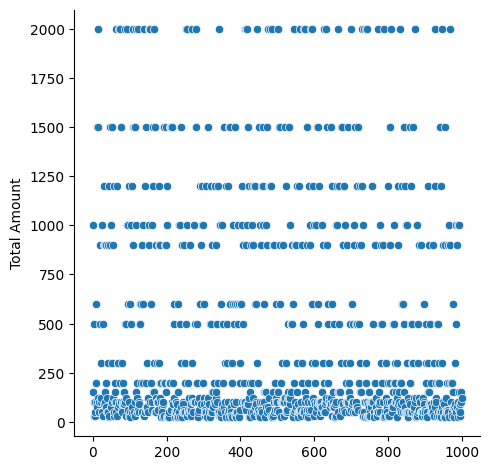

In [140]:
#time series analysis

sns.relplot(data=df['Total Amount'],kind='scatter')

In [141]:
#customer and product analysis

df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

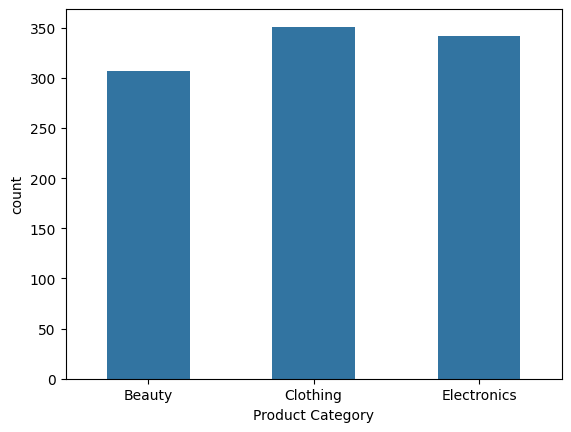

In [157]:
sns.countplot(x = df["Product Category"],width=0.5)
plt.show()

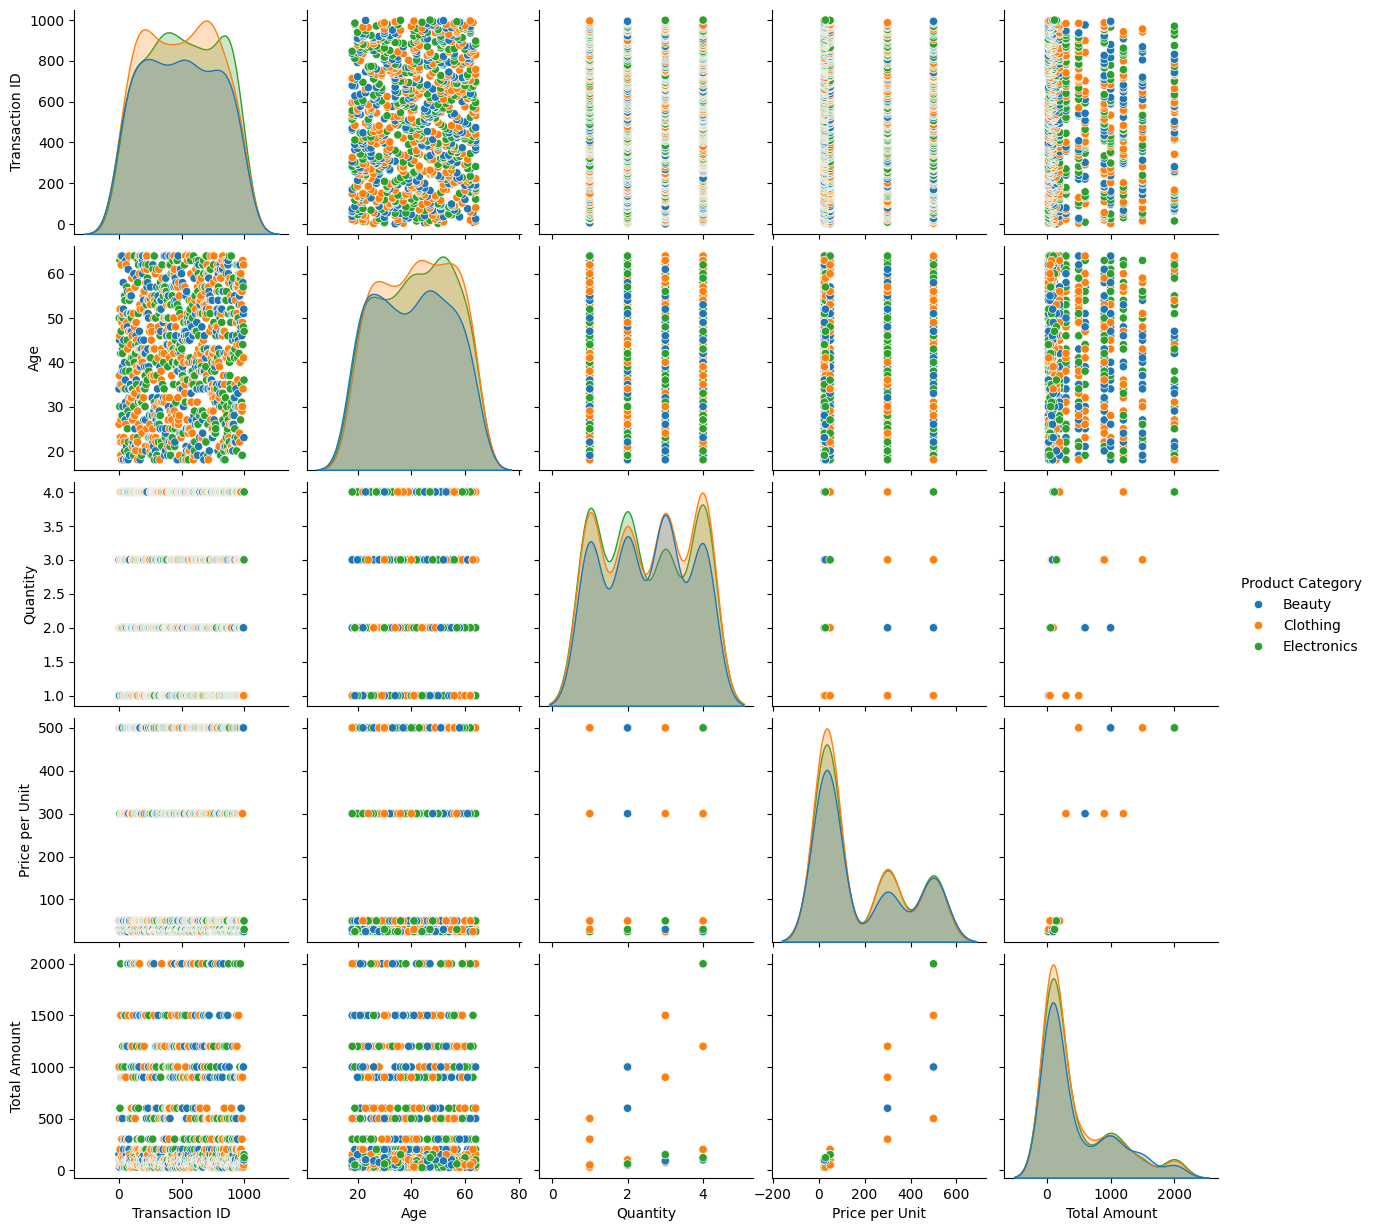

In [159]:
sns.pairplot(data = df, hue = "Product Category")
plt.show()

In [161]:
grp = df.groupby("Product Category")[["Quantity", "Total Amount"]].sum()
print(grp)

                  Quantity  Total Amount
Product Category                        
Beauty                 771        143515
Clothing               894        155580
Electronics            849        156905


In [163]:
cate = df["Product Category"].value_counts()
print(cate)

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


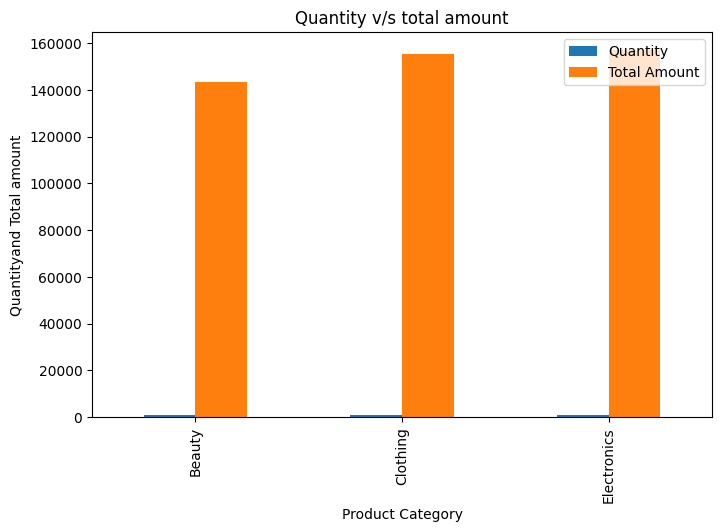

In [173]:
grp.plot(kind = "bar",figsize=(8,5))
plt.title("Quantity v/s total amount")
plt.ylabel("Quantityand Total amount")
plt.show()

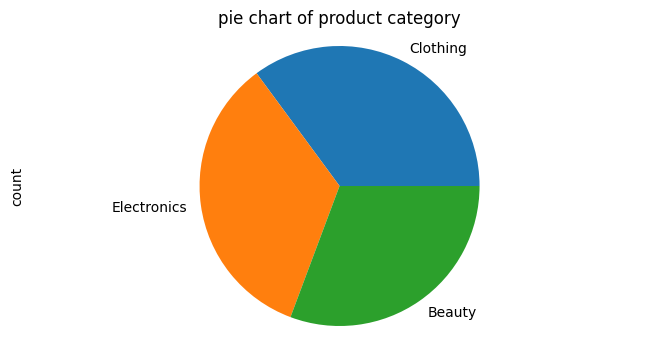

In [214]:
colour_list = ["red","green","blue"]
cate.plot(kind='pie',figsize=(8,4))
plt.title("pie chart of product category")
plt.axis("equal")
plt.show()

In [176]:
gen = df["Gender"].value_counts()
gen

Gender
Female    510
Male      490
Name: count, dtype: int64

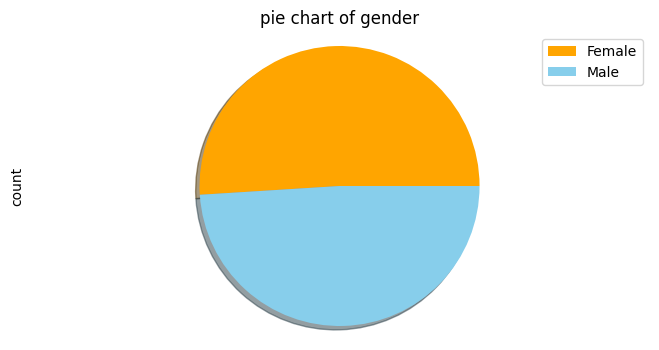

In [207]:
gen.plot(kind="pie",figsize=(8,4),shadow=True, labels=None,colors=["orange","skyblue"])
gender_list = ['Female', 'Male']
plt.title("pie chart of gender")
plt.axis("equal")
plt.legend(labels=gender_list,loc="upper right")
plt.show()

In [202]:
df["Price per Unit"].corr(df["Total Amount"])

np.float64(0.8519248403554026)

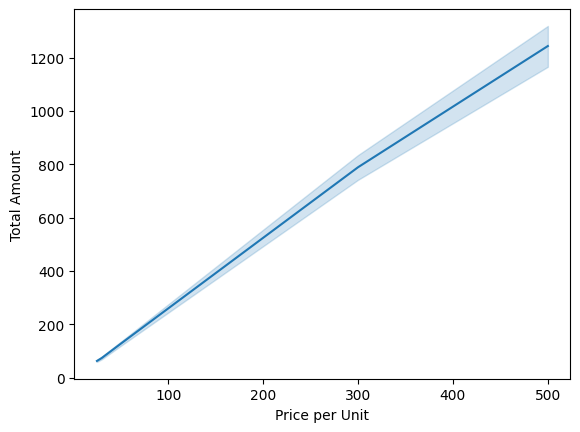

In [203]:
sns.lineplot(x="Price per Unit",y="Total Amount",data=df)
plt.show()